# Task 3 — AnnData Tutorial

**References:**
- [AnnData Getting Started](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html)
- [scverse AnnData Tutorial](https://scverse-tutorials.readthedocs.io/en/latest/notebooks/anndata_getting_started.html)

**AnnData** is the core data structure for single-cell analysis in Python. It stores expression matrices alongside cell and gene metadata in one unified object.

---

In [2]:
!pip install anndata scanpy matplotlib pandas numpy

import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

print('AnnData version:', ad.__version__)
print('Scanpy version:', sc.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
AnnData version: 0.12.11
Scan

## Part 1 — Create an AnnData Object from Scratch

In [3]:
# Simulate a small expression matrix: 5 cells × 4 genes
np.random.seed(42)
n_cells, n_genes = 5, 4

X = np.random.randint(0, 100, size=(n_cells, n_genes)).astype(np.float32)

# Cell metadata (obs)
obs = pd.DataFrame({
    'cell_type':    ['T cell', 'B cell', 'NK cell', 'T cell', 'Monocyte'],
    'n_counts':     X.sum(axis=1),
    'batch':        ['batch1', 'batch1', 'batch2', 'batch2', 'batch1'],
}, index=[f'cell_{i}' for i in range(n_cells)])

# Gene metadata (var)
var = pd.DataFrame({
    'gene_name':    ['CD3D', 'CD19', 'GNLY', 'CD14'],
    'is_marker':    [True, True, True, True],
}, index=['CD3D', 'CD19', 'GNLY', 'CD14'])

# Create AnnData
adata = ad.AnnData(X=X, obs=obs, var=var)

print('Created AnnData object:')
print(adata)

Created AnnData object:
AnnData object with n_obs × n_vars = 5 × 4
    obs: 'cell_type', 'n_counts', 'batch'
    var: 'gene_name', 'is_marker'


## Part 2 — Explore the AnnData Structure

In [4]:
print('=== .X — Expression matrix ===')
print(adata.X)
print(f'Shape: {adata.X.shape}  (cells × genes)\n')

print('=== .obs — Cell metadata ===')
print(adata.obs)
print()

print('=== .var — Gene metadata ===')
print(adata.var)
print()

print('=== Shape ===')
print(f'{adata.n_obs} cells × {adata.n_vars} genes')

=== .X — Expression matrix ===
[[51. 92. 14. 71.]
 [60. 20. 82. 86.]
 [74. 74. 87. 99.]
 [23.  2. 21. 52.]
 [ 1. 87. 29. 37.]]
Shape: (5, 4)  (cells × genes)

=== .obs — Cell metadata ===
       cell_type  n_counts   batch
cell_0    T cell     228.0  batch1
cell_1    B cell     248.0  batch1
cell_2   NK cell     334.0  batch2
cell_3    T cell      98.0  batch2
cell_4  Monocyte     154.0  batch1

=== .var — Gene metadata ===
     gene_name  is_marker
CD3D      CD3D       True
CD19      CD19       True
GNLY      GNLY       True
CD14      CD14       True

=== Shape ===
5 cells × 4 genes


## Part 3 — Add Embeddings to `.obsm`

Embeddings added:
AxisArrays with keys: X_pca, X_umap


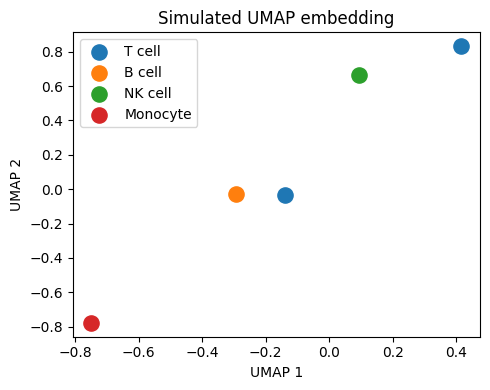

Plot saved.


In [5]:
# Store a 2D PCA-like embedding (simulated)
adata.obsm['X_pca'] = np.random.randn(n_cells, 2)
adata.obsm['X_umap'] = np.random.randn(n_cells, 2)

print('Embeddings added:')
print(adata.obsm)

# Plot the simulated UMAP
fig, ax = plt.subplots(figsize=(5, 4))
cell_types = adata.obs['cell_type']
for ct in cell_types.unique():
    mask = cell_types == ct
    ax.scatter(
        adata.obsm['X_umap'][mask, 0],
        adata.obsm['X_umap'][mask, 1],
        label=ct, s=120
    )
ax.set_title('Simulated UMAP embedding')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()
plt.tight_layout()
plt.savefig('simulated_umap.png', dpi=80)
plt.show()
print('Plot saved.')

## Part 4 — Add Unstructured Metadata to `.uns`

In [6]:
# .uns stores any unstructured data (dicts, strings, arrays)
adata.uns['experiment'] = 'PBMC Demo'
adata.uns['species'] = 'Homo sapiens'
adata.uns['sequencing_platform'] = '10X Chromium'

print('Unstructured metadata (.uns):')
for key, val in adata.uns.items():
    print(f'  {key}: {val}')

Unstructured metadata (.uns):
  experiment: PBMC Demo
  species: Homo sapiens
  sequencing_platform: 10X Chromium


## Part 5 — Add Multiple Layers

In [7]:
# Layers allow storing multiple versions of the expression matrix
adata.layers['raw_counts'] = adata.X.copy()
adata.layers['normalized'] = adata.X / adata.X.sum(axis=1, keepdims=True) * 10000
adata.layers['log1p'] = np.log1p(adata.layers['normalized'])

print('Layers stored:')
for name in adata.layers:
    print(f'  {name}: shape {adata.layers[name].shape}')

print('\nRaw counts (layer):')
print(pd.DataFrame(adata.layers['raw_counts'], index=adata.obs_names, columns=adata.var_names))

print('\nLog-normalized (layer):')
print(pd.DataFrame(adata.layers['log1p'].round(3), index=adata.obs_names, columns=adata.var_names))

Layers stored:
  raw_counts: shape (5, 4)
  normalized: shape (5, 4)
  log1p: shape (5, 4)

Raw counts (layer):
        CD3D  CD19  GNLY  CD14
cell_0  51.0  92.0  14.0  71.0
cell_1  60.0  20.0  82.0  86.0
cell_2  74.0  74.0  87.0  99.0
cell_3  23.0   2.0  21.0  52.0
cell_4   1.0  87.0  29.0  37.0

Log-normalized (layer):
         CD3D   CD19   GNLY   CD14
cell_0  7.713  8.303  6.422  8.044
cell_1  7.792  6.694  8.104  8.152
cell_2  7.704  7.704  7.865  7.995
cell_3  7.761  5.323  7.670  8.577
cell_4  4.189  8.639  7.541  7.785


## Part 6 — Subsetting AnnData

In [8]:
# Subset by cell type — like pandas boolean indexing
t_cells = adata[adata.obs['cell_type'] == 'T cell']
print(f'T cells only: {t_cells.n_obs} cells × {t_cells.n_vars} genes')
print(t_cells.obs)

# Subset by batch
batch1 = adata[adata.obs['batch'] == 'batch1']
print(f'\nBatch 1 only: {batch1.n_obs} cells')

# Subset specific genes
selected_genes = adata[:, ['CD3D', 'CD19']]
print(f'\nSelected genes shape: {selected_genes.shape}')

T cells only: 2 cells × 4 genes
       cell_type  n_counts   batch
cell_0    T cell     228.0  batch1
cell_3    T cell      98.0  batch2

Batch 1 only: 3 cells

Selected genes shape: (5, 2)


## Part 7 — Concatenate Two AnnData Objects

In [9]:
# Create a second dataset (e.g. from a second sample)
X2 = np.random.randint(0, 80, size=(3, n_genes)).astype(np.float32)
obs2 = pd.DataFrame({
    'cell_type': ['B cell', 'T cell', 'Monocyte'],
    'n_counts':  X2.sum(axis=1),
    'batch':     ['batch3', 'batch3', 'batch3'],
}, index=['cell_5', 'cell_6', 'cell_7'])

adata2 = ad.AnnData(X=X2, obs=obs2, var=var)

# Concatenate
combined = ad.concat([adata, adata2], label='dataset', keys=['sample1', 'sample2'])
print(f'Combined AnnData: {combined.n_obs} cells × {combined.n_vars} genes')
print(combined.obs)

Combined AnnData: 8 cells × 4 genes
       cell_type  n_counts   batch  dataset
cell_0    T cell     228.0  batch1  sample1
cell_1    B cell     248.0  batch1  sample1
cell_2   NK cell     334.0  batch2  sample1
cell_3    T cell      98.0  batch2  sample1
cell_4  Monocyte     154.0  batch1  sample1
cell_5    B cell     179.0  batch3  sample2
cell_6    T cell     192.0  batch3  sample2
cell_7  Monocyte      58.0  batch3  sample2


## Part 8 — Save and Load AnnData (.h5ad format)

In [10]:
# Save to HDF5-based .h5ad format
adata.write_h5ad('my_anndata.h5ad')
print('Saved: my_anndata.h5ad')

# Reload from disk
adata_loaded = ad.read_h5ad('my_anndata.h5ad')
print('Loaded back from disk:')
print(adata_loaded)

Saved: my_anndata.h5ad
Loaded back from disk:
AnnData object with n_obs × n_vars = 5 × 4
    obs: 'cell_type', 'n_counts', 'batch'
    var: 'gene_name', 'is_marker'
    uns: 'experiment', 'sequencing_platform', 'species'
    obsm: 'X_pca', 'X_umap'
    layers: 'log1p', 'normalized', 'raw_counts'


## Part 9 — Apply AnnData on Real PBMC 3K Data

In [11]:
# Load the processed PBMC 3K dataset
pbmc = sc.datasets.pbmc3k_processed()
print('PBMC 3K AnnData:')
print(pbmc)
print()

# Inspect structure
print('Cell metadata columns:', list(pbmc.obs.columns))
print('Gene metadata columns:', list(pbmc.var.columns))
print('Embeddings available:', list(pbmc.obsm.keys()))
print('Uns keys:', list(pbmc.uns.keys())[:5])

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

PBMC 3K AnnData:
AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Cell metadata columns: ['n_genes', 'percent_mito', 'n_counts', 'louvain']
Gene metadata columns: ['n_cells']
Embeddings available: ['X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr']
Uns keys: ['draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca']


In [12]:
# Show cell type distribution
print('Cell type counts:')
print(pbmc.obs['louvain'].value_counts())

# Subset to B cells
b_cells = pbmc[pbmc.obs['louvain'] == 'B cells']
print(f'\nB cells: {b_cells.n_obs} cells')

# Save
pbmc.write_h5ad('pbmc3k_anndata_demo.h5ad')
print('Saved pbmc3k_anndata_demo.h5ad')

Cell type counts:
louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64

B cells: 342 cells
Saved pbmc3k_anndata_demo.h5ad


---
## Summary — AnnData Cheat Sheet

| Attribute | What it stores | Access example |
|---|---|---|
| `.X` | Expression matrix (cells × genes) | `adata.X` |
| `.obs` | Cell metadata DataFrame | `adata.obs['cell_type']` |
| `.var` | Gene metadata DataFrame | `adata.var['highly_variable']` |
| `.obsm` | Cell embeddings (PCA, UMAP) | `adata.obsm['X_umap']` |
| `.varm` | Gene embeddings (PCA loadings) | `adata.varm['PCs']` |
| `.obsp` | Cell-cell distances / graphs | `adata.obsp['connectivities']` |
| `.uns` | Unstructured metadata | `adata.uns['neighbors']` |
| `.layers` | Alternative expression matrices | `adata.layers['raw_counts']` |
| `.raw` | Unprocessed counts backup | `adata.raw.X` |

```python
# Common operations
adata[mask, :]           # subset cells
adata[:, gene_list]      # subset genes
ad.concat([a1, a2])      # concatenate
adata.write_h5ad(path)   # save
ad.read_h5ad(path)       # load
```